# DATA IMPORT AND OVERVIEW

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv('../data/student_depression_dataset.csv')

In [4]:
df.head(5)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [5]:
df.shape

(27901, 18)

In [6]:
# Rename
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.rename(columns={'have_you_ever_had_suicidal_thoughts_?':'suicidal_thoughts'}, inplace=True)

In [7]:
df

,id,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,work/study_hours,financial_stress,family_history_of_mental_illness,depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,'Less than 5 hours',Healthy,'Class 12',Yes,10.0,5.0,No,1


# EDA (Exploratory Data Analysis)

## Thông tin chung về dữ liệu

### Kiểm tra kiểu dữ liệu của từng cột và giá trị null

In [8]:
df.dtypes

id                                    int64
gender                               object
age                                 float64
city                                 object
profession                           object
academic_pressure                   float64
work_pressure                       float64
cgpa                                float64
study_satisfaction                  float64
job_satisfaction                    float64
sleep_duration                       object
dietary_habits                       object
degree                               object
suicidal_thoughts                    object
work/study_hours                    float64
financial_stress                     object
family_history_of_mental_illness     object
depression                            int64
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                27901 non-null  int64  
 1   gender                            27901 non-null  object 
 2   age                               27901 non-null  float64
 3   city                              27901 non-null  object 
 4   profession                        27901 non-null  object 
 5   academic_pressure                 27901 non-null  float64
 6   work_pressure                     27901 non-null  float64
 7   cgpa                              27901 non-null  float64
 8   study_satisfaction                27901 non-null  float64
 9   job_satisfaction                  27901 non-null  float64
 10  sleep_duration                    27901 non-null  object 
 11  dietary_habits                    27901 non-null  object 
 12  degr

<Axes: >

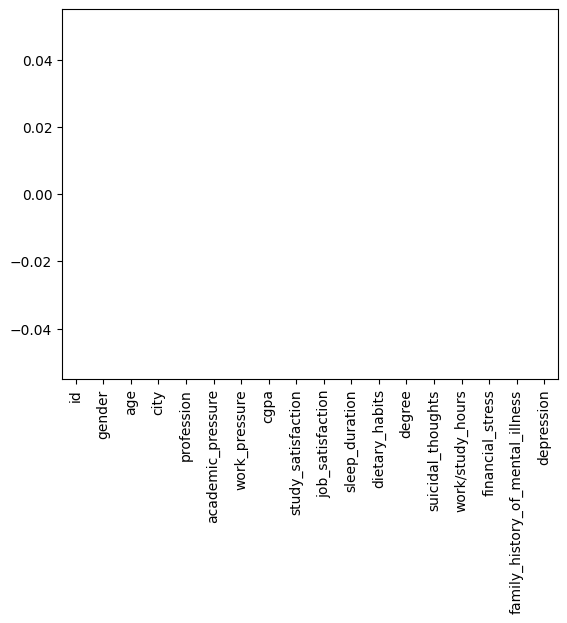

In [10]:
df.isna().mean()
(df.isna().sum()/df.shape[0]).sort_values().plot(kind='bar')
# Not null

## Thống kê mô tả

In [11]:
# df.describe()
df_num = df.describe().round(2)
df_num

,id,age,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,work/study_hours,depression
count,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00
mean,70442.15,25.82,3.14,0.00,7.66,2.94,0.00,7.16,0.59
std,40641.18,4.91,1.38,0.04,1.47,1.36,0.04,3.71,0.49
min,2.00,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,35039.00,21.00,2.00,0.00,6.29,2.00,0.00,4.00,0.00
50%,70684.00,25.00,3.00,0.00,7.77,3.00,0.00,8.00,1.00
75%,105818.00,30.00,4.00,0.00,8.92,4.00,0.00,10.00,1.00
max,140699.00,59.00,5.00,5.00,10.00,5.00,4.00,12.00,1.00


In [12]:
df_cat = df.describe(include=['object'])
df_cat

,gender,city,profession,sleep_duration,dietary_habits,degree,suicidal_thoughts,financial_stress,family_history_of_mental_illness
count,27901,27901,27901,27901,27901,27901,27901,27901,27901
unique,2,52,14,5,4,28,2,6,2
top,Male,Kalyan,Student,'Less than 5 hours',Unhealthy,'Class 12',Yes,5.0,No
freq,15547,1570,27870,8310,10317,6080,17656,6715,14398


In [13]:
df['financial_stress'].value_counts()

financial_stress
5.0    6715
4.0    5775
3.0    5226
1.0    5121
2.0    5061
?         3
Name: count, dtype: int64

In [14]:
df = df.replace('?', np.nan)
df['financial_stress'] = df['financial_stress'].astype(float)
df['financial_stress'].value_counts()

financial_stress
5.0    6715
4.0    5775
3.0    5226
1.0    5121
2.0    5061
Name: count, dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                27901 non-null  int64  
 1   gender                            27901 non-null  object 
 2   age                               27901 non-null  float64
 3   city                              27901 non-null  object 
 4   profession                        27901 non-null  object 
 5   academic_pressure                 27901 non-null  float64
 6   work_pressure                     27901 non-null  float64
 7   cgpa                              27901 non-null  float64
 8   study_satisfaction                27901 non-null  float64
 9   job_satisfaction                  27901 non-null  float64
 10  sleep_duration                    27901 non-null  object 
 11  dietary_habits                    27901 non-null  object 
 12  degr

In [16]:
# df.describe()
df_num = df.describe().round(2)
df_num

,id,age,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,work/study_hours,financial_stress,depression
count,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27898.00,27901.00
mean,70442.15,25.82,3.14,0.00,7.66,2.94,0.00,7.16,3.14,0.59
std,40641.18,4.91,1.38,0.04,1.47,1.36,0.04,3.71,1.44,0.49
min,2.00,18.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
25%,35039.00,21.00,2.00,0.00,6.29,2.00,0.00,4.00,2.00,0.00
50%,70684.00,25.00,3.00,0.00,7.77,3.00,0.00,8.00,3.00,1.00
75%,105818.00,30.00,4.00,0.00,8.92,4.00,0.00,10.00,4.00,1.00
max,140699.00,59.00,5.00,5.00,10.00,5.00,4.00,12.00,5.00,1.00


In [17]:
df_cat = df.describe(include=['object'])
df_cat

,gender,city,profession,sleep_duration,dietary_habits,degree,suicidal_thoughts,family_history_of_mental_illness
count,27901,27901,27901,27901,27901,27901,27901,27901
unique,2,52,14,5,4,28,2,2
top,Male,Kalyan,Student,'Less than 5 hours',Unhealthy,'Class 12',Yes,No
freq,15547,1570,27870,8310,10317,6080,17656,14398


## Phân tích biến mục tiêu (target)

<Axes: xlabel='depression'>

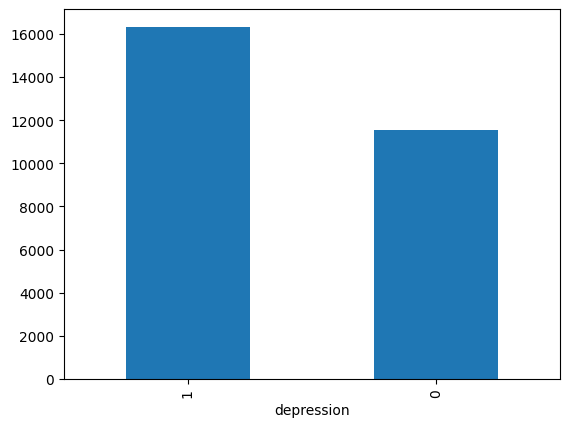

In [18]:
df['depression'].value_counts().plot(kind='bar')
# balance

In [19]:
df['depression'].value_counts(normalize=True)

depression
1    0.585499
0    0.414501
Name: proportion, dtype: float64

## Phân tích, kiểm tra từng đặc trưng


### Category

In [20]:
(df['gender'].value_counts(normalize=True)).to_frame() 
# balance

,proportion
gender,
Male,0.55722
Female,0.44278


In [21]:
df['city'].value_counts()

""" Kiểm tra tương quan giữa city với 
 target xem môi trường có ảnh hưởng hay không"""

' Kiểm tra tương quan giữa city với \n target xem môi trường có ảnh hưởng hay không'

In [22]:
df['profession'].value_counts()
""" feature này lệch quá -> có khả năng bỏ luôn"""

' feature này lệch quá -> có khả năng bỏ luôn'

In [23]:
df['sleep_duration'].value_counts()
# balance

sleep_duration
'Less than 5 hours'    8310
'7-8 hours'            7346
'5-6 hours'            6183
'More than 8 hours'    6044
Others                   18
Name: count, dtype: int64

In [24]:
df['dietary_habits'].value_counts()
# balance

dietary_habits
Unhealthy    10317
Moderate      9921
Healthy       7651
Others          12
Name: count, dtype: int64

In [25]:
df['financial_stress'].value_counts()
# balance

financial_stress
5.0    6715
4.0    5775
3.0    5226
1.0    5121
2.0    5061
Name: count, dtype: int64

### Numerical

array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'academic_pressure'}>,
        <Axes: title={'center': 'work_pressure'}>]], dtype=object)

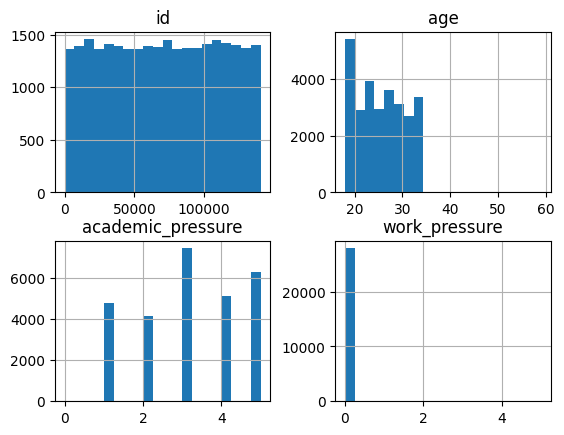

In [26]:
df_num = df.select_dtypes(include=['number']).columns
df[df_num].iloc[:,0:4].hist(bins=20)

In [27]:
df['work_pressure'].value_counts()

work_pressure
0.0    27898
5.0        2
2.0        1
Name: count, dtype: int64

array([[<Axes: title={'center': 'cgpa'}>,
        <Axes: title={'center': 'study_satisfaction'}>],
       [<Axes: title={'center': 'job_satisfaction'}>,
        <Axes: title={'center': 'work/study_hours'}>]], dtype=object)

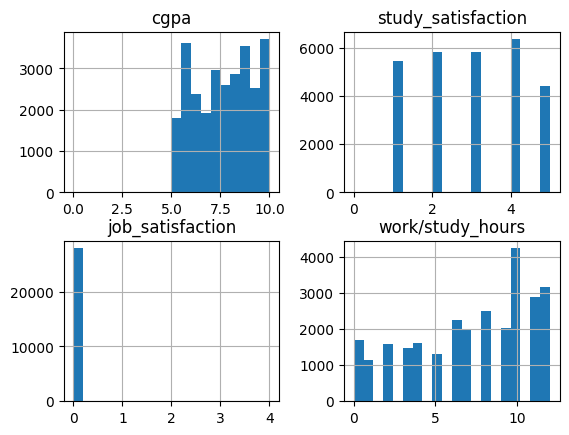

In [28]:
df[df_num].iloc[:,4:8].hist(bins=20)

In [29]:
df['job_satisfaction'].value_counts()

job_satisfaction
0.0    27893
2.0        3
4.0        2
1.0        2
3.0        1
Name: count, dtype: int64

## Phân tích đa biến (Multivariate Analysis)

### Mối quan hệ giữa các biến phân loại và biến mục tiêu

<Axes: xlabel='sleep_duration', ylabel='count'>

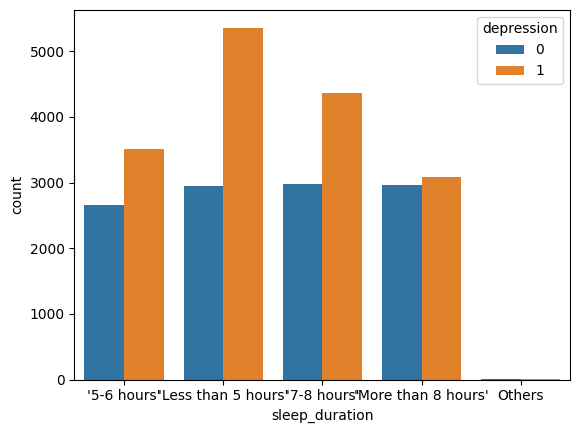

In [30]:
sns.countplot(x='sleep_duration', hue='depression', data=df)


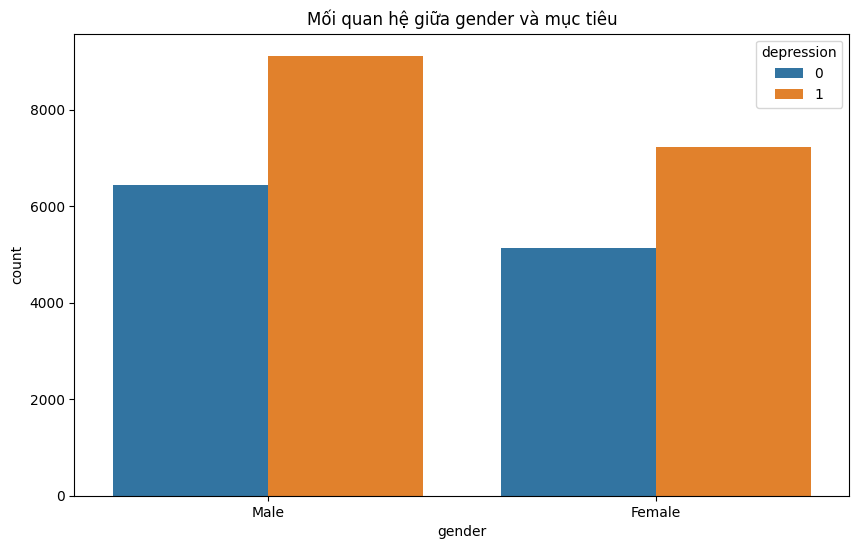

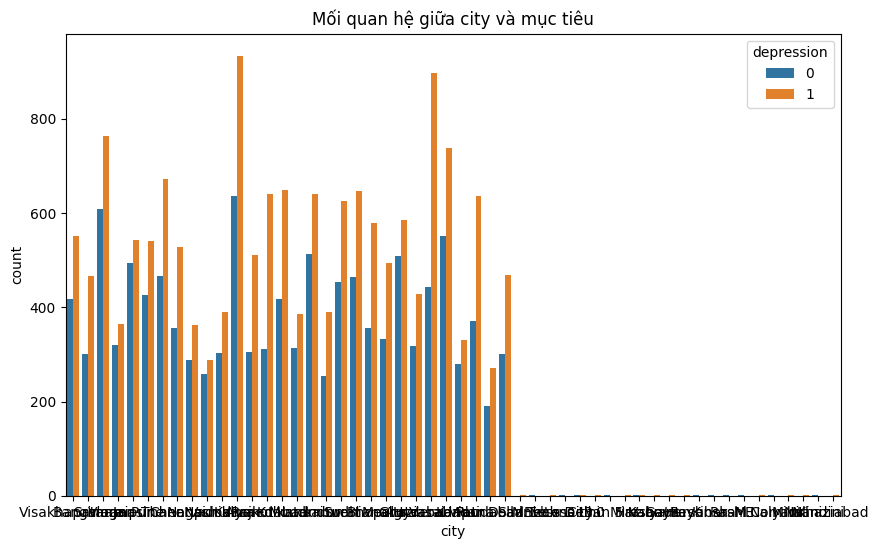

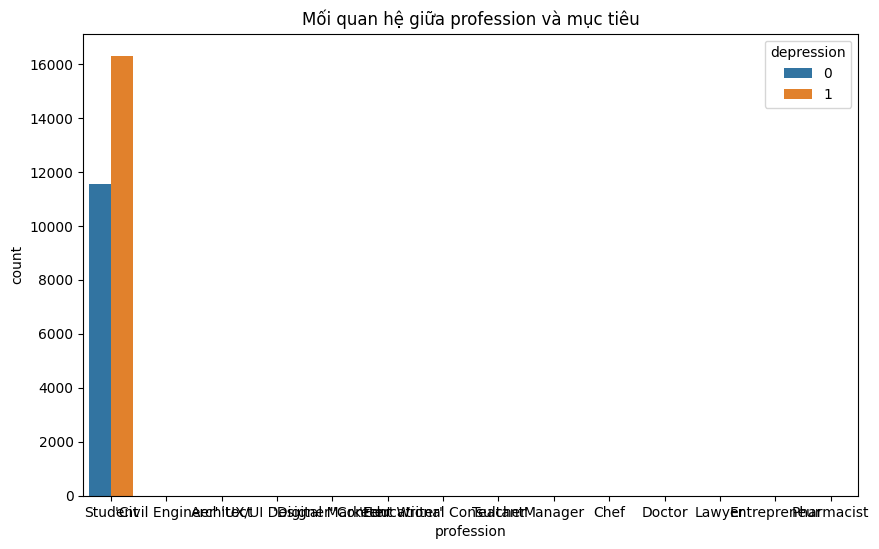

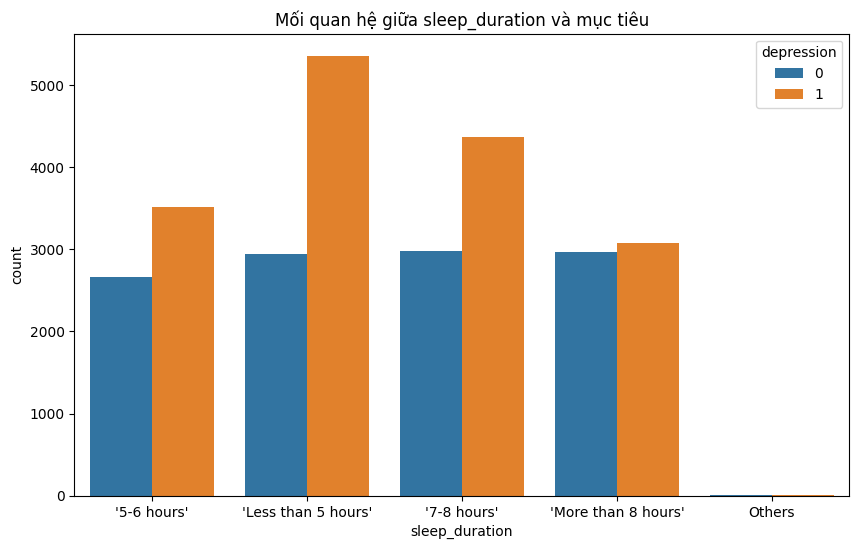

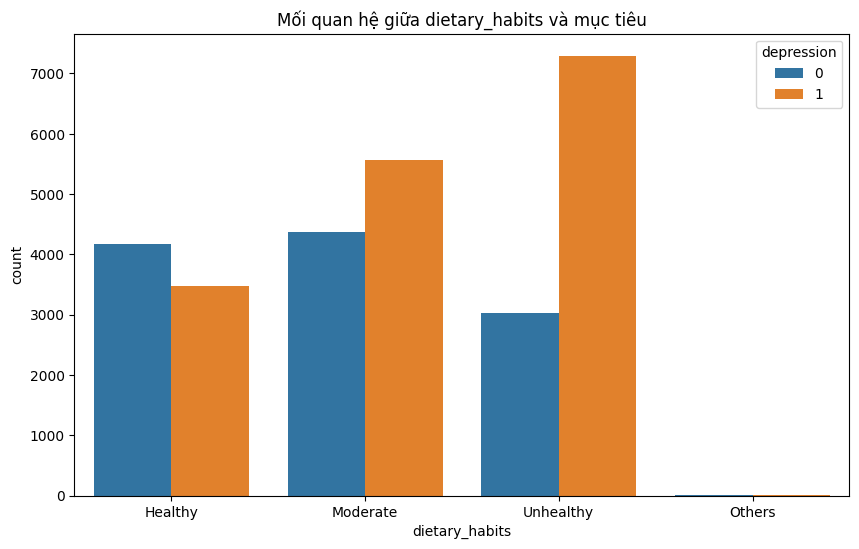

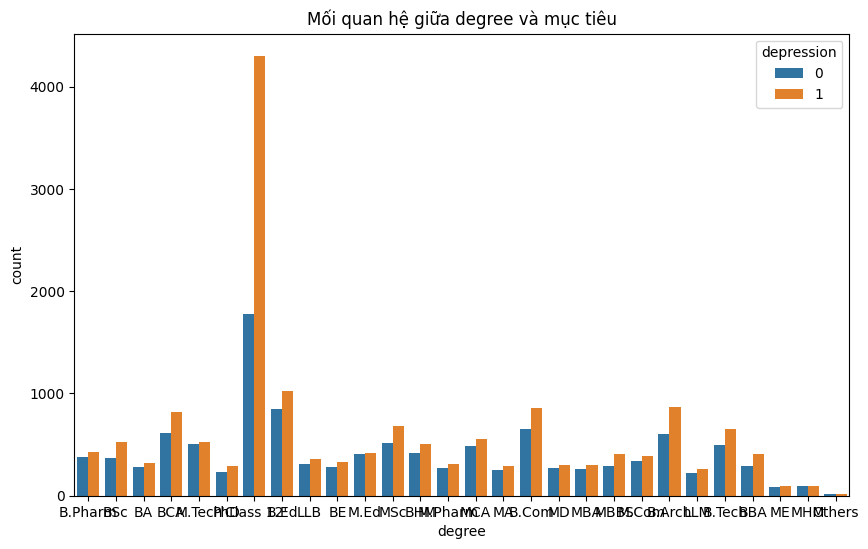

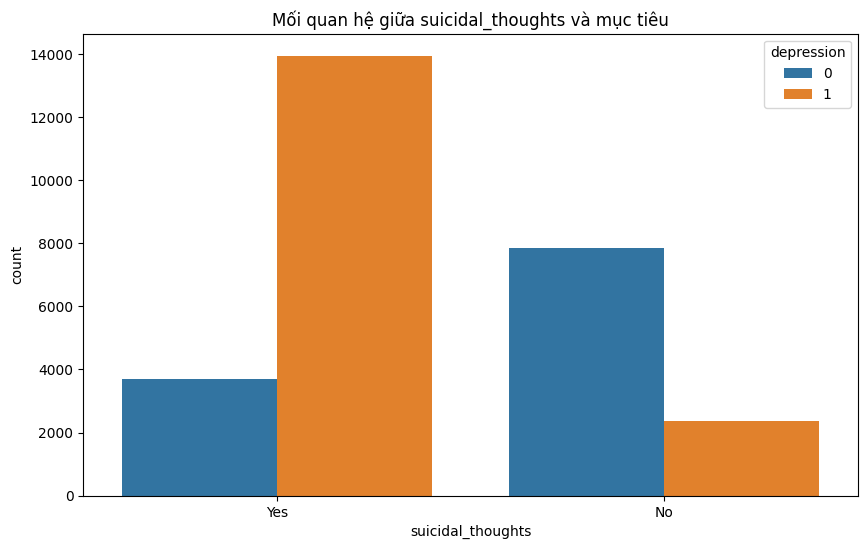

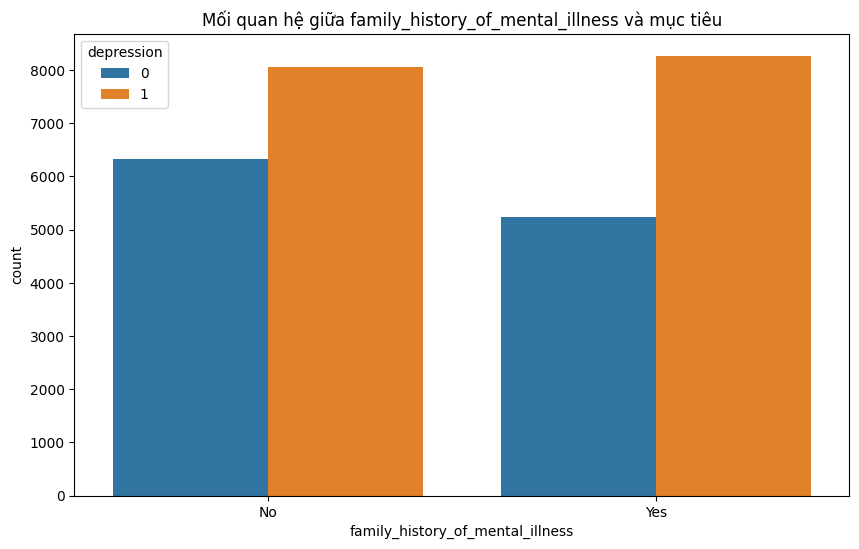

In [31]:
numeric_cols = df.select_dtypes(exclude=np.number).columns
for col in numeric_cols:
    plt.figure(figsize=(10,6))
    sns.countplot(x=col, hue='depression', data=df)
    plt.title(f'Mối quan hệ giữa {col} và mục tiêu')
    plt.show()


## Phân tích tương quan (Correlation Analysis)
Kiểm tra mức độ tương quan tuyến tính giữa các biến số.

In [32]:
df.corr(numeric_only=True)
# df.corr() chỉ dùng cho đặc trưng số

,id,age,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,work/study_hours,financial_stress,depression
id,1.000000,0.003783,0.005172,0.001261,-0.012324,0.007794,0.001931,-0.004466,0.000783,0.000923
age,0.003783,1.000000,-0.075803,0.002015,0.005056,0.009235,-0.000432,-0.032928,-0.095026,-0.226422
academic_pressure,0.005172,-0.075803,1.000000,-0.022231,-0.022239,-0.110988,-0.024945,0.095970,0.151706,0.474835
work_pressure,0.001261,0.002015,-0.022231,1.000000,-0.050896,-0.021145,0.770652,-0.005468,0.001883,-0.003351
cgpa,-0.012324,0.005056,-0.022239,-0.050896,1.000000,-0.044062,-0.053631,0.002604,0.005885,0.022210
study_satisfaction,0.007794,0.009235,-0.110988,-0.021145,-0.044062,1.000000,-0.021907,-0.036441,-0.065107,-0.167971
job_satisfaction,0.001931,-0.000432,-0.024945,0.770652,-0.053631,-0.021907,1.000000,-0.005222,0.005248,-0.003482
work/study_hours,-0.004466,-0.032928,0.095970,-0.005468,0.002604,-0.036441,-0.005222,1.000000,0.075283,0.208563
financial_stress,0.000783,-0.095026,0.151706,0.001883,0.005885,-0.065107,0.005248,0.075283,1.000000,0.363591
depression,0.000923,-0.226422,0.474835,-0.003351,0.022210,-0.167971,-0.003482,0.208563,0.363591,1.000000


In [33]:
df.corr(numeric_only=True, method='spearman')

,id,age,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,work/study_hours,financial_stress,depression
id,1.000000,0.004108,0.004909,0.001337,-0.011583,0.007918,0.004819,-0.003852,0.000256,0.000931
age,0.004108,1.000000,-0.076939,-0.002982,0.007109,0.008355,-0.007330,-0.029164,-0.095513,-0.225313
academic_pressure,0.004909,-0.076939,1.000000,-0.018377,-0.023835,-0.115964,-0.021475,0.091187,0.149989,0.472367
work_pressure,0.001337,-0.002982,-0.018377,1.000000,-0.017956,-0.018339,0.612361,-0.007088,0.000894,-0.005308
cgpa,-0.011583,0.007109,-0.023835,-0.017956,1.000000,-0.046082,-0.016507,0.003129,0.006061,0.021785
study_satisfaction,0.007918,0.008355,-0.115964,-0.018339,-0.046082,1.000000,-0.019242,-0.035158,-0.064156,-0.168160
job_satisfaction,0.004819,-0.007330,-0.021475,0.612361,-0.016507,-0.019242,1.000000,-0.005650,0.005711,-0.002940
work/study_hours,-0.003852,-0.029164,0.091187,-0.007088,0.003129,-0.035158,-0.005650,1.000000,0.072052,0.200673
financial_stress,0.000256,-0.095513,0.149989,0.000894,0.006061,-0.064156,0.005711,0.072052,1.000000,0.362809
depression,0.000931,-0.225313,0.472367,-0.005308,0.021785,-0.168160,-0.002940,0.200673,0.362809,1.000000


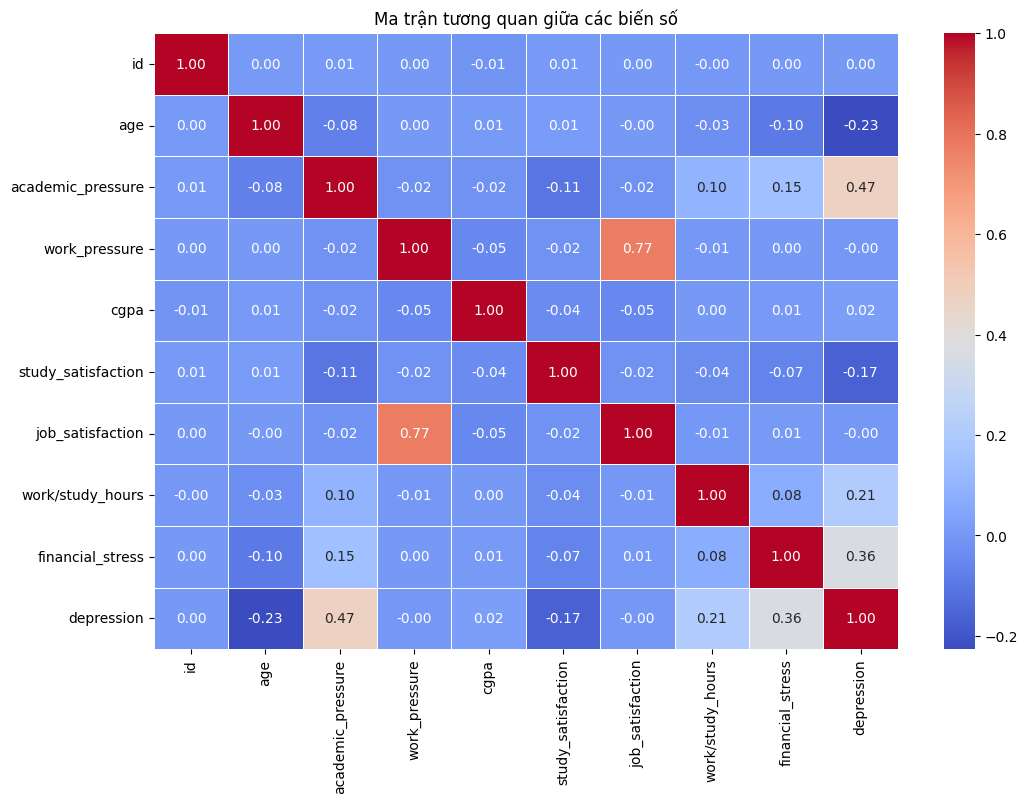

In [34]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

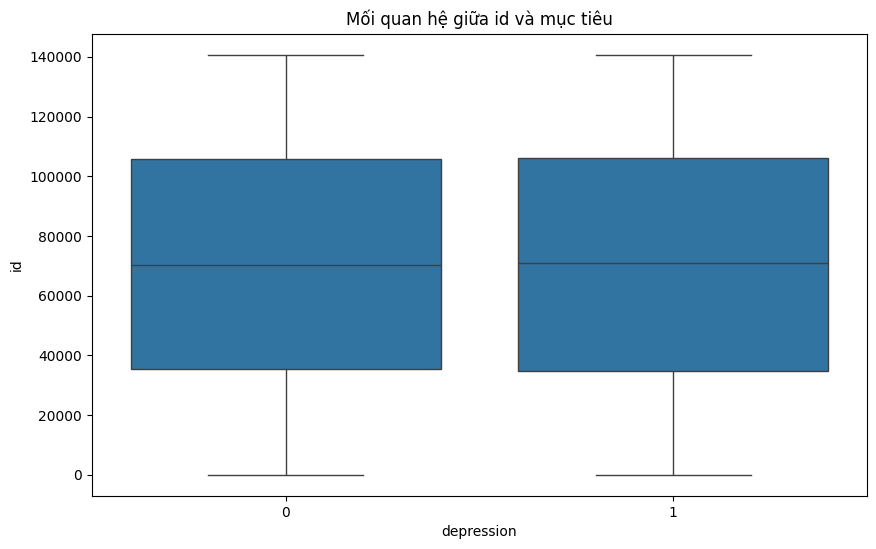

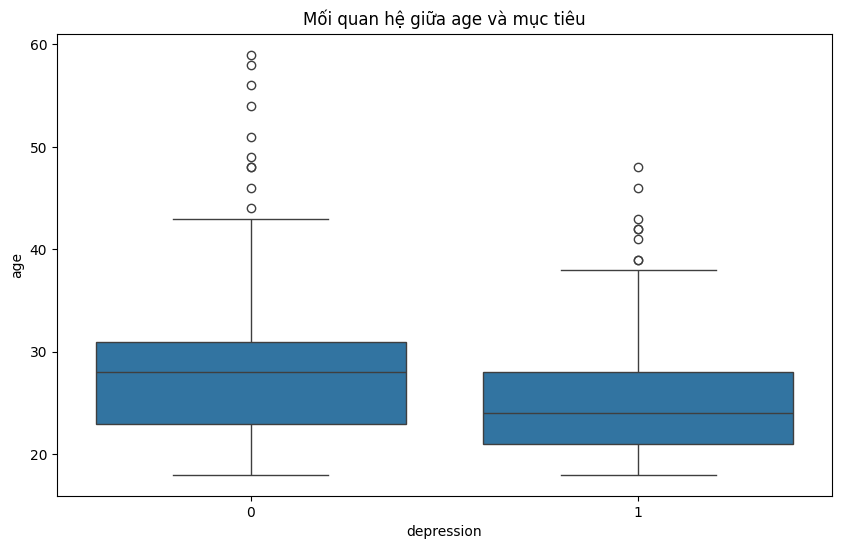

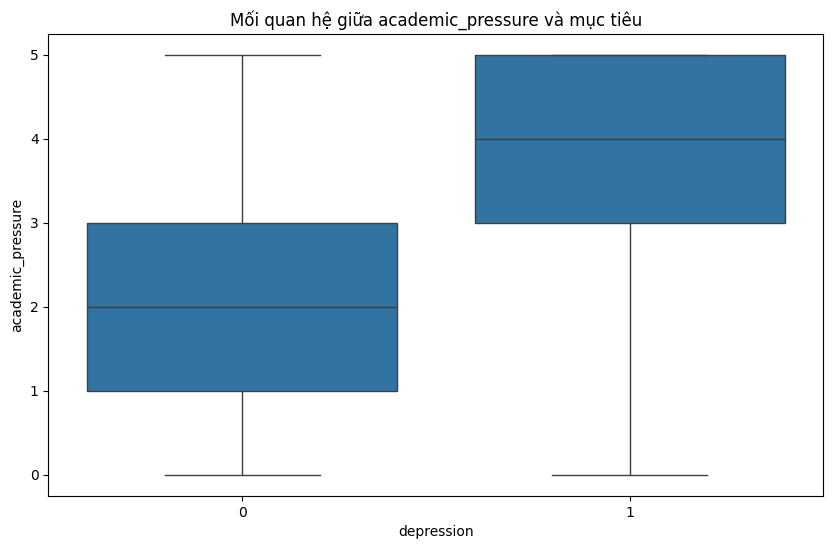

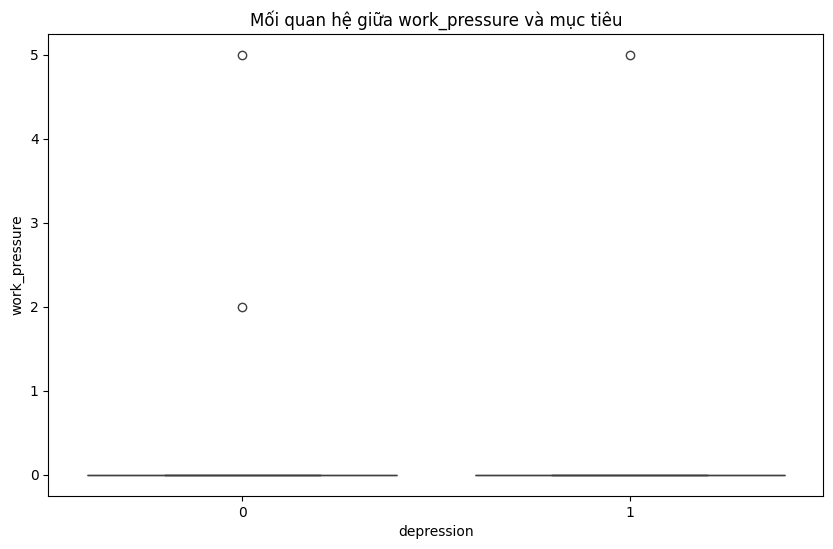

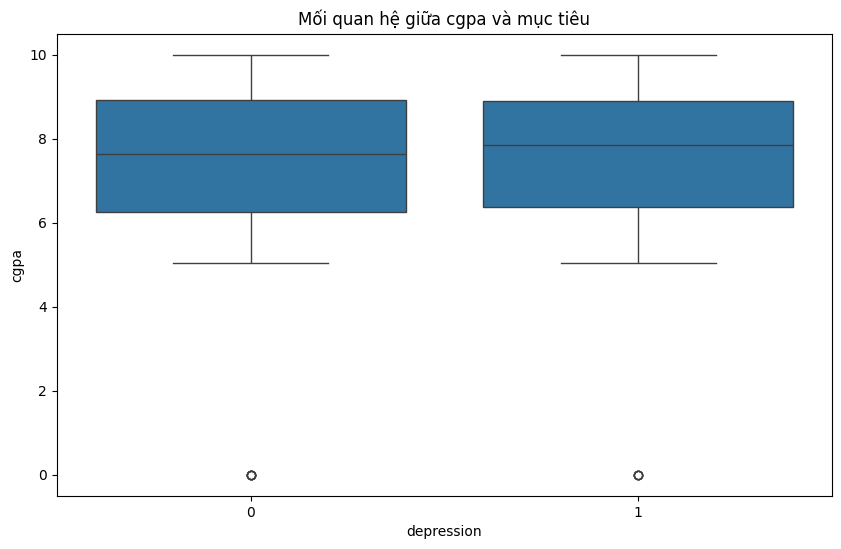

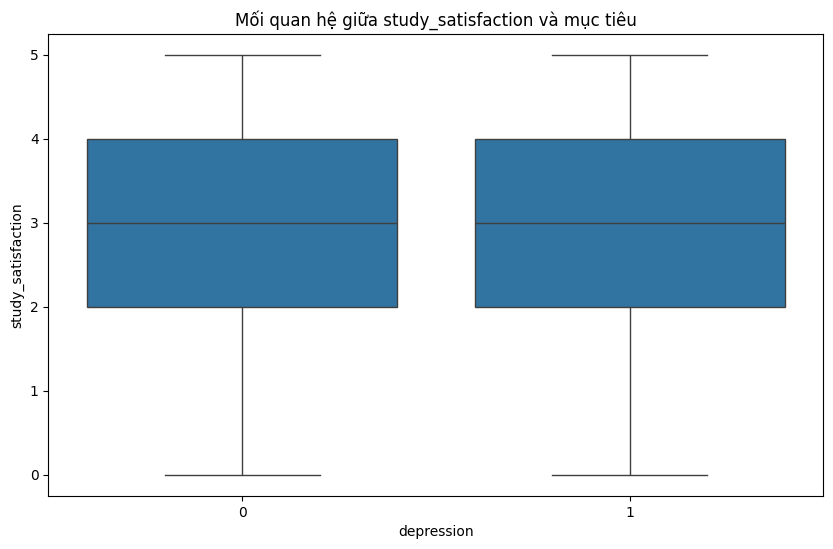

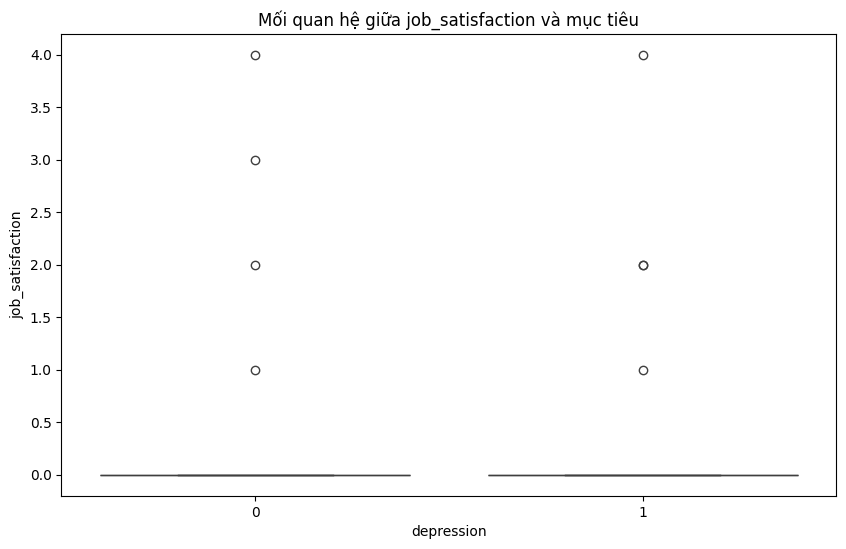

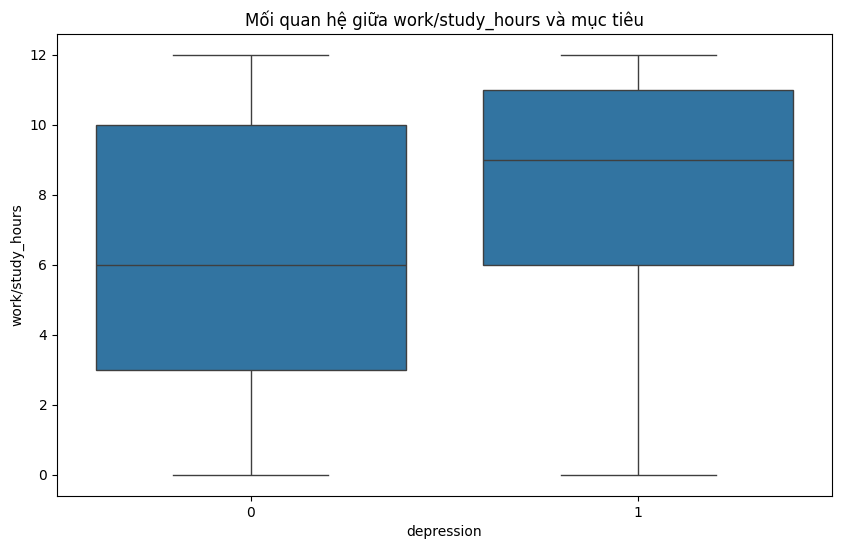

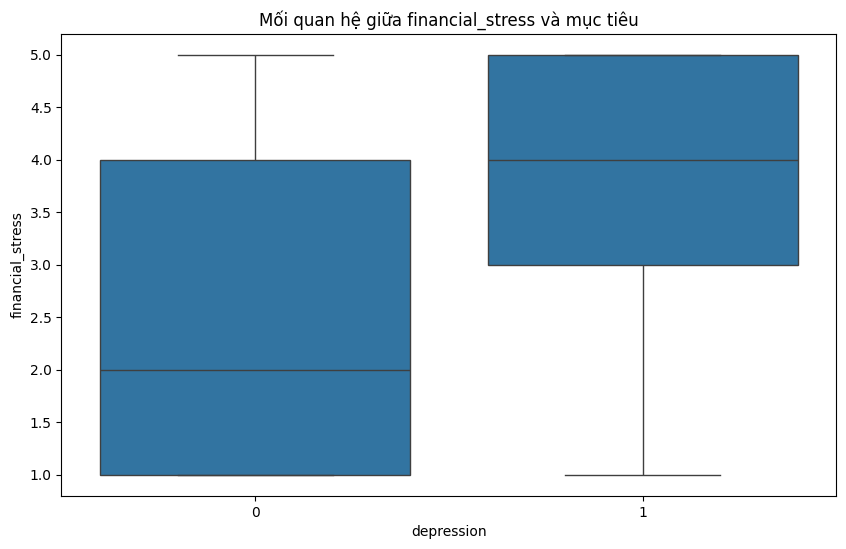

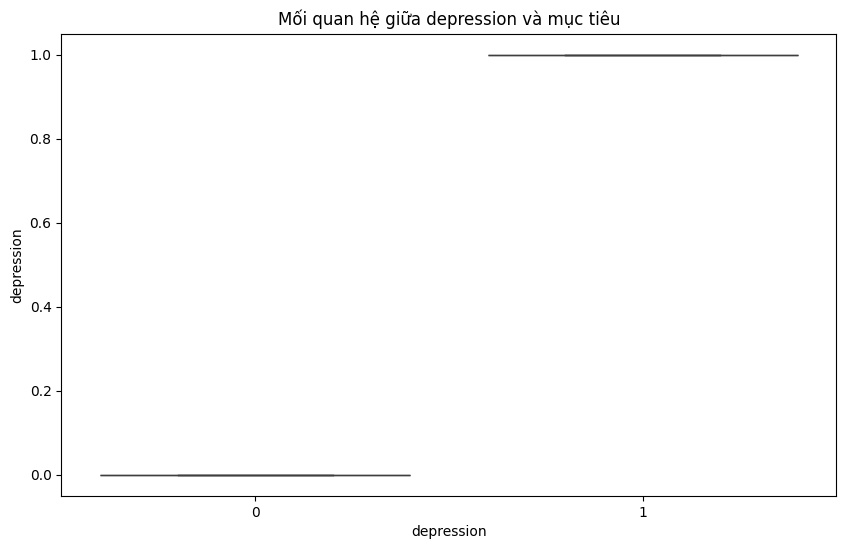

In [35]:
# Phân tích mối quan hệ giữa các biến số và biến mục tiêu
for col in numeric_cols:
    plt.figure(figsize=(10,6))
    sns.boxplot(x='depression', y=col, data=df)
    plt.title(f'Mối quan hệ giữa {col} và mục tiêu')
    plt.show()

In [36]:
df

,id,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,work/study_hours,financial_stress,family_history_of_mental_illness,depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,'Less than 5 hours',Healthy,'Class 12',Yes,10.0,5.0,No,1


In [37]:
## Delete: id, city, profession
## Binary encode: gender, suicidal_thoughts, family_...
## Ordinal encode: sleep_duration, degree
## One-hot encode: dietary habit

# Feature Engineering

## Feature Transformer

### Missing Value Imputation
Ở đây chỉ có đặc trưng financial_stress

In [38]:
# MCAR -> dùng mode - most-frequent
df['financial_stress'] = df['financial_stress'].fillna(df['financial_stress'].mode()[0])
print("Tổng số missing values hiện tại:", df.isna().sum().sum())


Tổng số missing values hiện tại: 0


In [39]:
df.shape

(27901, 18)

In [40]:
df['degree'].value_counts()

degree
'Class 12'    6080
B.Ed          1867
B.Com         1506
B.Arch        1478
BCA           1433
MSc           1190
B.Tech        1152
MCA           1044
M.Tech        1022
BHM            925
BSc            888
M.Ed           821
B.Pharm        810
M.Com          734
BBA            696
MBBS           696
LLB            671
BE             613
BA             600
M.Pharm        582
MD             572
MBA            562
MA             544
PhD            522
LLM            482
MHM            191
ME             185
Others          35
Name: count, dtype: int64

In [41]:
df['dietary_habits'] = df['dietary_habits'].replace('Others',df['dietary_habits'].mode()[0])

In [42]:
df['dietary_habits'].value_counts()

dietary_habits
Unhealthy    10329
Moderate      9921
Healthy       7651
Name: count, dtype: int64

### Handling Categorical Feature
Encoding feature

In [43]:
# Binary Encoding cho biến Y/N
binary_cols = ['suicidal_thoughts', 'family_history_of_mental_illness']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

# Ordinal Encoding cho biến phân loại 
sleep_duration_mapping = {'\'Less than 5 hours\'': 0, '\'5-6 hours\'': 1, '\'7-8 hours\'': 2, '\'More than 8 hours\'': 3, 'Others': 4}
degree_map = {
    '\'Class 12\'': 0,
    'B.Ed': 1, 'B.Com': 1, 'B.Arch': 1, 'BCA': 1, 'B.Tech': 1,
    'BHM': 1, 'BSc': 1, 'B.Pharm': 1, 'BBA': 1, 'MBBS': 1,
    'LLB': 1, 'BE': 1, 'BA': 1,
    'MSc': 2, 'MCA': 2, 'M.Tech': 2, 'M.Ed': 2, 'M.Com': 2,
    'M.Pharm': 2, 'MBA': 2, 'MA': 2, 'MHM': 2, 'ME': 2, 'LLM': 2,
    'PhD': 3, 'MD': 3,
    'Others': 4
}
df['sleep_duration'] = df['sleep_duration'].map(sleep_duration_mapping)
df['degree'] = df['degree'].map(degree_map)

# One-hot Encoding
nominal_cols = ['dietary_habits']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=False)

print("Kích thước dữ liệu sau khi mã hoá:", df.shape)

Kích thước dữ liệu sau khi mã hoá: (27901, 20)


In [44]:
df['sleep_duration'].value_counts()

sleep_duration
0    8310
2    7346
1    6183
3    6044
4      18
Name: count, dtype: int64

In [45]:
df['degree'].value_counts()

degree
1    13335
2     7357
0     6080
3     1094
4       35
Name: count, dtype: int64

In [46]:
df = df.drop(['id', 'city' , 'profession'], axis=1)
df

,gender,age,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,degree,suicidal_thoughts,work/study_hours,financial_stress,family_history_of_mental_illness,depression,dietary_habits_Healthy,dietary_habits_Moderate,dietary_habits_Unhealthy
0,0,33.0,5.0,0.0,8.97,2.0,0.0,1,1,1,3.0,1.0,0,1,True,False,False
1,1,24.0,2.0,0.0,5.90,5.0,0.0,1,1,0,3.0,2.0,1,0,False,True,False
2,0,31.0,3.0,0.0,7.03,5.0,0.0,0,1,0,9.0,1.0,1,0,True,False,False
3,1,28.0,3.0,0.0,5.59,2.0,0.0,2,1,1,4.0,5.0,1,1,False,True,False
4,1,25.0,4.0,0.0,8.13,3.0,0.0,1,2,1,1.0,1.0,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,1,27.0,5.0,0.0,5.75,5.0,0.0,1,0,1,7.0,1.0,1,0,False,False,True
27897,0,27.0,2.0,0.0,9.40,3.0,0.0,0,2,0,0.0,3.0,1,0,True,False,False
27898,0,31.0,3.0,0.0,6.61,4.0,0.0,1,3,0,12.0,2.0,0,0,False,False,True
27899,1,18.0,5.0,0.0,6.88,2.0,0.0,0,0,1,10.0,5.0,0,1,True,False,False


### Feature Scaling
Không cần vì các model có base model là Decision Tree, chia theo ngưỡng

## Feature Construction

In [47]:
# ===== FEATURE ENGINEERING: Tạo thêm Features Mới =====
# Các features mới được tạo từ sự kết hợp của các features hiện có

# 1. Stress Score: tổng hợp các yếu tố stress chính
df['stress_score'] = df['academic_pressure'] + df['work_pressure'] + df['financial_stress']

# 2. Satisfaction Score: tổng hợp mức độ hài lòng
df['satisfaction_score'] = df['study_satisfaction'] + df['job_satisfaction']

# 3. Khoảng cách giữa áp lực học và sự hài lòng (cao = nguy hiểm)
df['pressure_satisfaction_gap'] = df['academic_pressure'] - df['study_satisfaction']

# 4. Số giờ làm/học so với thời gian ngủ
df['work_hours_per_sleep'] = df['work/study_hours'] / (df['sleep_duration'] + 1)

# 5. Tỷ lệ CGPA so với áp lực học tập
df['cgpa_pressure_ratio'] = df['cgpa'] / (df['academic_pressure'] + 1)

print('Shape sau Feature Engineering:', df.shape)
df.head()

Shape sau Feature Engineering: (27901, 22)


,gender,age,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,degree,suicidal_thoughts,...,family_history_of_mental_illness,depression,dietary_habits_Healthy,dietary_habits_Moderate,dietary_habits_Unhealthy,stress_score,satisfaction_score,pressure_satisfaction_gap,work_hours_per_sleep,cgpa_pressure_ratio
0,0,33.0,5.0,0.0,8.97,2.0,0.0,1,1,1,...,0,1,True,False,False,6.0,2.0,3.0,1.500000,1.495000
1,1,24.0,2.0,0.0,5.90,5.0,0.0,1,1,0,...,1,0,False,True,False,4.0,5.0,-3.0,1.500000,1.966667
2,0,31.0,3.0,0.0,7.03,5.0,0.0,0,1,0,...,1,0,True,False,False,4.0,5.0,-2.0,9.000000,1.757500
3,1,28.0,3.0,0.0,5.59,2.0,0.0,2,1,1,...,1,1,False,True,False,8.0,2.0,1.0,1.333333,1.397500
4,1,25.0,4.0,0.0,8.13,3.0,0.0,1,2,1,...,0,0,False,True,False,5.0,3.0,1.0,0.500000,1.626000


## Feature Extraction

## Feature Selection

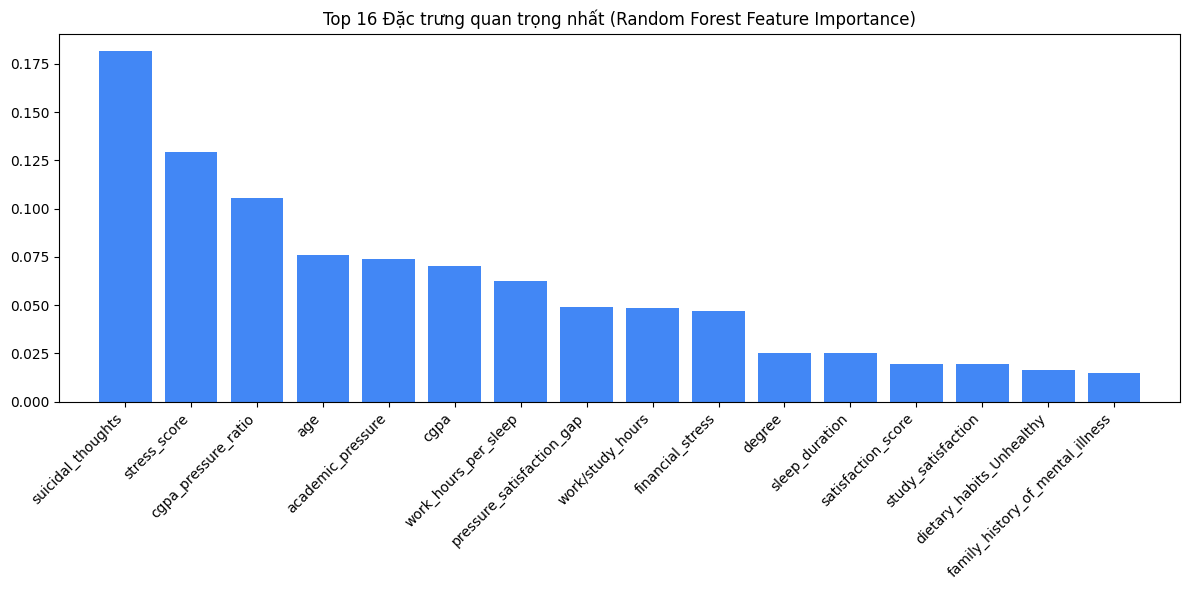

Tập dữ liệu sau cùng (Features Set) sẵn sàng để Training có shape là: (27901, 21)


In [48]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Tách biến Explainatory (X) và biến mục tiêu (y)
X = df.drop('depression', axis=1)
# X = X.drop('suicidal_thoughts', axis=1)
y = df['depression']


# 2. Chia Train/Test TRƯỚC (Data Splitting)
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest để lấy ra các features tốt nhất
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_raw, y_train)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

top_k = 16
top_features = [X.columns[i] for i in indices][:top_k]

# Trực quan hoá Top 20 Features
plt.figure(figsize=(12, 6))
plt.title(f"Top {top_k} Đặc trưng quan trọng nhất (Random Forest Feature Importance)")
plt.bar(range(top_k), importances[indices][:top_k], align="center", color='#4287f5')
plt.xticks(range(top_k), top_features, rotation=45, ha='right')
plt.xlim([-1, top_k])
plt.tight_layout()
plt.show()

# Gán lại tập dữ liệu X với các top features
X_final = X  # Sử dụng toàn bộ features (bao gồm cả features mới)
print("Tập dữ liệu sau cùng (Features Set) sẵn sàng để Training có shape là:", X_final.shape)


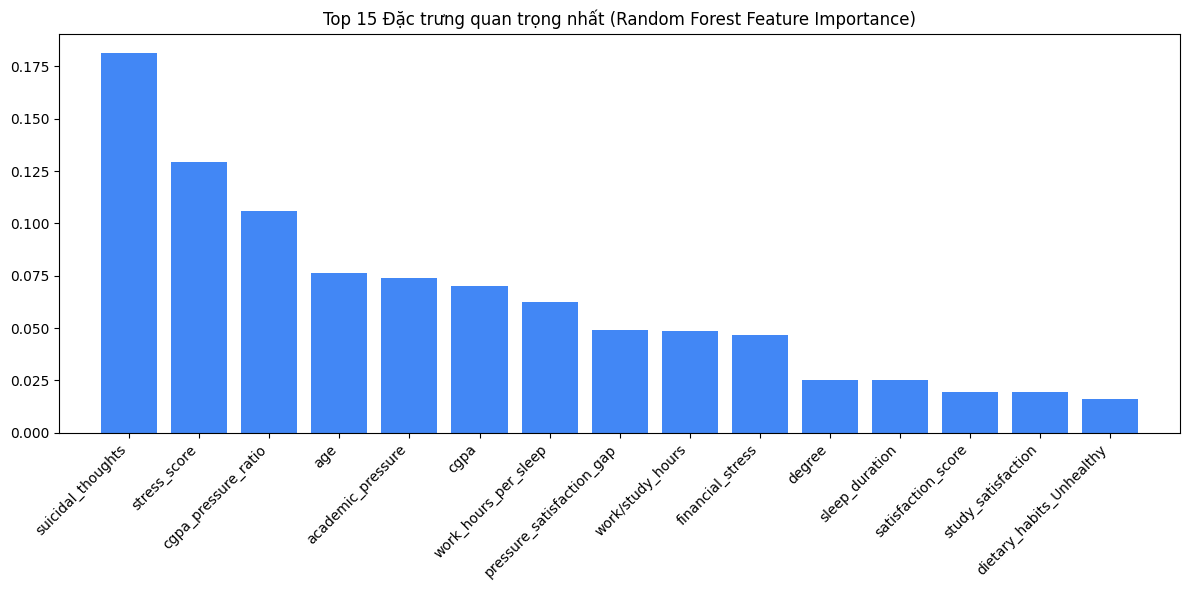

In [49]:
top_k = 15
top_features = [X.columns[i] for i in indices][:top_k]

# Trực quan hoá Top 20 Features
plt.figure(figsize=(12, 6))
plt.title(f"Top {top_k} Đặc trưng quan trọng nhất (Random Forest Feature Importance)")
plt.bar(range(top_k), importances[indices][:top_k], align="center", color='#4287f5')
plt.xticks(range(top_k), top_features, rotation=45, ha='right')
plt.xlim([-1, top_k])
plt.tight_layout()
plt.show()

# Data Splitting and Build Model

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")


Kích thước tập Train: (22320, 21)
Kích thước tập Test: (5581, 21)


In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Khởi tạo mô hình Decision Tree, dùng class_weight='balanced' do dữ liệu mất cân bằng
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10)
rf_model = RandomForestClassifier(n_estimators=500, random_state=42, max_depth=10, min_samples_leaf=5, min_samples_split=10)
# rf_model = RandomForestClassifier(n_estimators=500, random_state=42, max_depth=None)
# Huấn luyện mô hình
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)


,n_estimators,500
,criterion,'gini'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
# Dự đoán trên tập train và tập test

# y_train_pred = dt_model.predict(X_train)
# y_test_pred = dt_model.predict(X_test)
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Model Validation

--- Đánh giá trên tập Train ---
Accuracy : 0.8772
Precision: 0.8801
Recall   : 0.9150
F1-Score : 0.8972
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      9252
           1       0.88      0.91      0.90     13068

    accuracy                           0.88     22320
   macro avg       0.88      0.87      0.87     22320
weighted avg       0.88      0.88      0.88     22320



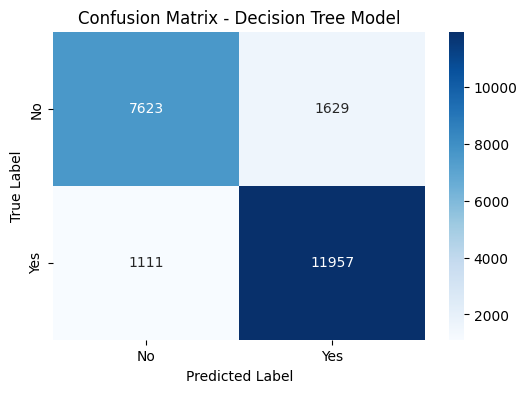

--- Đánh giá trên tập Test ---
Accuracy : 0.8421
Precision: 0.8528
Recall   : 0.8828
F1-Score : 0.8675
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      2313
           1       0.85      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.84      5581
weighted avg       0.84      0.84      0.84      5581



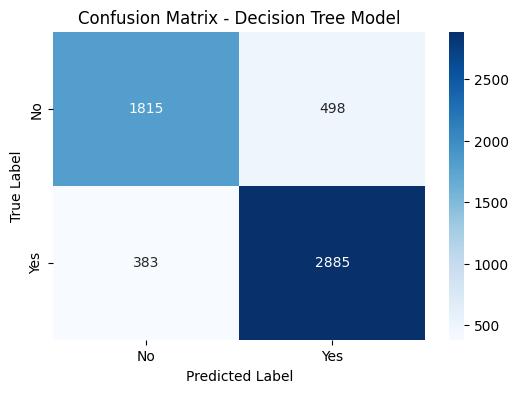

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# Hàm tính toán và in 4 loại metric
def evaluate_model(y_true, y_pred, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"--- Đánh giá trên tập {dataset_name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")

    # In Classification Report chi tiết cho tập Test
    print("Classification Report (Test Data):")
    print(classification_report(y_true, y_pred))

    # Vẽ Confusion Matrix cho tập Test
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - Decision Tree Model')
    plt.show()

# In đánh giá
evaluate_model(y_train, y_train_pred, "Train")
evaluate_model(y_test, y_test_pred, "Test")



# model = rf_model
# X = X_final
# dt_acc = cross_val_score(model, X, y, scoring='accuracy', cv=5)
# dt_f1 = cross_val_score(model, X, y, scoring='f1_weighted', cv=5)
# dt_rec = cross_val_score(model, X, y, scoring='recall_weighted', cv=5)
# dt_prec = cross_val_score(model, X, y, scoring='precision_weighted', cv=5)

# print("Result K-fold:")
# print("Accuracy:",dt_acc.mean(), dt_acc.std())
# print("Precision:",dt_prec.mean(), dt_prec.std())
# print("Recall:", dt_rec.mean(), dt_rec.std())
# print("F1-score:",dt_f1.mean(), dt_f1.std())




# Tuning Hyperparameter

## Tune xgboost

In [54]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_grid = {
    'n_estimators': [500, 300, 200],
    'max_depth': [3, 5, 6, 10],
    'learning_rate': [0.05, 0.75, 0.1]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
)

grid.fit(X_train, y_train)
print(grid.best_params_)   # tham số tốt nhất
print(grid.best_score_)    # score tốt nhất
best_model = grid.best_estimator_

c:\Users\Bui Trong Nguyen\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:26:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500}
0.8721668673117767


In [65]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsampl=0.8,          # Lấy mẫu 80% data mỗi cây (hiệu quả giảm overfit)
    colsample_bytreee=0.8,   # Lấy 80% features mỗi split
    random_state=42
)
xgb_model.fit(X_train, y_train)
# y_train_pred = xgb_model.predict(X_train)
# y_test_pred = xgb_model.predict(X_test)
# y_test_pred_xgb = xgb_model.predict(X_test)

c:\Users\Bui Trong Nguyen\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:43:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "colsample_bytreee", "subsampl" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


--- Đánh giá trên tập Test (XGBoost) ---
Accuracy : 0.8420
Precision: 0.8561
Recall   : 0.8776
F1-Score : 0.8667
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.82      0.79      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.84      5581
weighted avg       0.84      0.84      0.84      5581



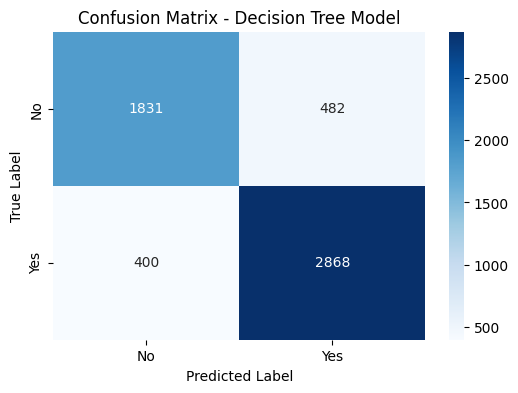

In [66]:
y_test_pred_xgb = xgb_model.predict(X_test)
evaluate_model(y_test, y_test_pred_xgb, 'Test (XGBoost)')

## Tune LightBGM

In [62]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV

model = lgb.LGBMClassifier()

# param_dist = {
#     'num_leaves': [31, 50, 70],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'n_estimators': [100, 200],
#     'max_depth': [-1, 5, 10],
#     'min_child_samples': [20, 50, 100],
# }
param_grid = {
    'n_estimators': [200, 500, 800],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'subsample': [0.7, 0.8, 1.0],          # bagging_fraction
    'colsample_bytree': [0.7, 0.8, 1.0],   # feature_fraction
    'min_child_samples': [20, 50, 100],

}

search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    scoring='f1'
)

search.fit(X_train, y_train)
print(search.best_params_)   # tham số tốt nhất
print(search.best_score_)    # score tốt nhất
best_model = search.best_estimator_

{'num_leaves': 70, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.01}
0.8708041990139599


--- Đánh giá trên tập Train (LightGBM) ---
Accuracy : 0.8948
Precision: 0.8980
Recall   : 0.9254
F1-Score : 0.9115
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      9252
           1       0.90      0.93      0.91     13068

    accuracy                           0.89     22320
   macro avg       0.89      0.89      0.89     22320
weighted avg       0.89      0.89      0.89     22320



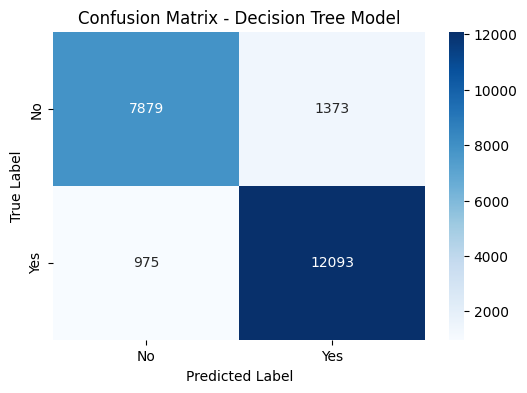

--- Đánh giá trên tập Test (LightGBM) ---
Accuracy : 0.8387
Precision: 0.8513
Recall   : 0.8779
F1-Score : 0.8644
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      2313
           1       0.85      0.88      0.86      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581



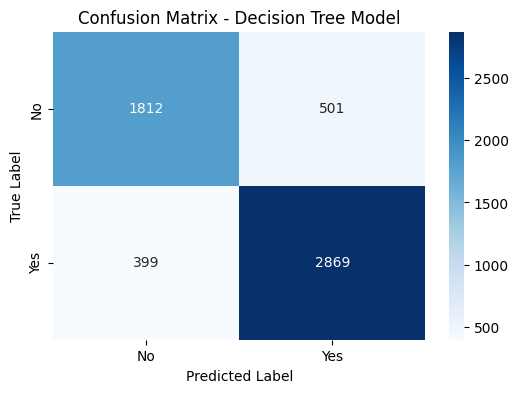

In [58]:
from lightgbm import LGBMClassifier

# LightGBM - thường cho accuracy cao hơn XGBoost và RF trên tabular data
lgb_model = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
y_train_pred_lgb = lgb_model.predict(X_train)
y_test_pred_lgb = lgb_model.predict(X_test)

evaluate_model(y_train, y_train_pred_lgb, 'Train (LightGBM)')
evaluate_model(y_test, y_test_pred_lgb, 'Test (LightGBM)')

## Tune RF

In [67]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [5, 6, 8, 10], 
    'min_samples_split': [5, 6, 8, 10],
    'min_samples_leaf': [6, 8, 5, 10]
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)
search.fit(X_train, y_train)
print(search.best_params_)   # tham số tốt nhất
print(search.best_score_)    # score tốt nhất
best_model = search.best_estimator_


{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_depth': 10}
0.871028837722769


In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10, min_samples_leaf=6, min_samples_split=10)

rf_model.fit(X_train, y_train)

y_test_pred_rf = rf_model.predict(X_test)
evaluate_model(y_test, y_test_pred_rf, 'Test (RF)')

--- Đánh giá trên tập Test (RF) ---
Accuracy : 0.8430
Precision: 0.8534
Recall   : 0.8837
F1-Score : 0.8683


# Ensemble Model - Voting

--- Đánh giá trên tập Train (Voting Ensemble) ---
Accuracy : 0.8672
Precision: 0.8735
Recall   : 0.9041
F1-Score : 0.8885
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      9252
           1       0.87      0.90      0.89     13068

    accuracy                           0.87     22320
   macro avg       0.87      0.86      0.86     22320
weighted avg       0.87      0.87      0.87     22320



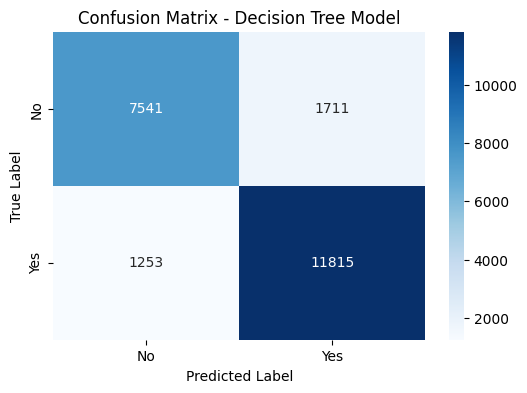

--- Đánh giá trên tập Test (Voting Ensemble) ---
Accuracy : 0.8425
Precision: 0.8546
Recall   : 0.8810
F1-Score : 0.8676
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.82      0.79      0.81      2313
           1       0.85      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.84      5581
weighted avg       0.84      0.84      0.84      5581



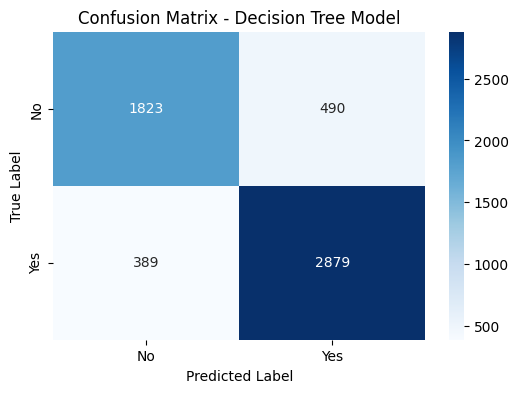

In [68]:
from sklearn.ensemble import VotingClassifier
# Khởi tạo mô hình Ensemble
ensemble = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=6, min_samples_split=10, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=500, max_depth=3, learning_rate=0.05, random_state=42)),
        ('lgbm', LGBMClassifier(n_estimators=500, max_depth=6, learning_rate=0.01, num_leaves=70, min_child_samples=20, random_state=42))
        # ('xgb2', XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)),

    ],
    voting='soft' # Dùng xác suất trung bình của các model
)
# Huấn luyện và dự đoán
ensemble.fit(X_train, y_train)
y_train_pred = ensemble.predict(X_train)
y_test_pred_ens = ensemble.predict(X_test)
# Đánh giá lại kết quả
# evaluate_model(y_train, y_train_pred, "Train")
# evaluate_model(y_test, y_test_pred, "Test")
evaluate_model(y_train, y_train_pred, "Train (Voting Ensemble)")
evaluate_model(y_test, y_test_pred_ens, "Test (Voting Ensemble)")

### Stacking

--- Đánh giá trên tập Train (Stacking Ensemble) ---
Accuracy : 0.8657
Precision: 0.8726
Recall   : 0.9024
F1-Score : 0.8872
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      9252
           1       0.87      0.90      0.89     13068

    accuracy                           0.87     22320
   macro avg       0.86      0.86      0.86     22320
weighted avg       0.87      0.87      0.87     22320



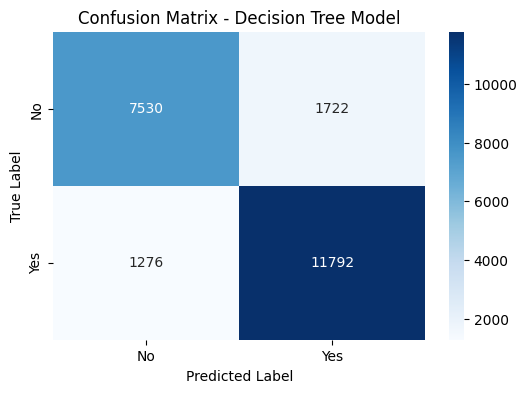

--- Đánh giá trên tập Test (Stacking Ensemble) ---
Accuracy : 0.8438
Precision: 0.8565
Recall   : 0.8807
F1-Score : 0.8684
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.82      0.79      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581



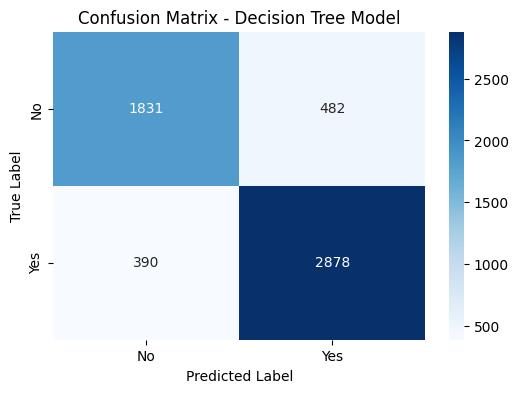

In [69]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Stacking Ensemble: mạnh hơn Voting Classifier
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=6, min_samples_split=10, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=500, max_depth=3, learning_rate=0.05, random_state=42)),
    ('lgbm', LGBMClassifier(n_estimators=500, max_depth=6, learning_rate=0.01, num_leaves=70, min_child_samples=20, random_state=42))
]

stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stacking.fit(X_train, y_train)
y_train_pred_stack = stacking.predict(X_train)
y_test_pred_stack = stacking.predict(X_test)

evaluate_model(y_train, y_train_pred_stack, 'Train (Stacking Ensemble)')
evaluate_model(y_test, y_test_pred_stack, 'Test (Stacking Ensemble)')

### Stacking 2

--- Đánh giá trên tập Train (Stacking Ensemble) ---
Accuracy : 0.8643
Precision: 0.8717
Recall   : 0.9009
F1-Score : 0.8861
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      9252
           1       0.87      0.90      0.89     13068

    accuracy                           0.86     22320
   macro avg       0.86      0.86      0.86     22320
weighted avg       0.86      0.86      0.86     22320



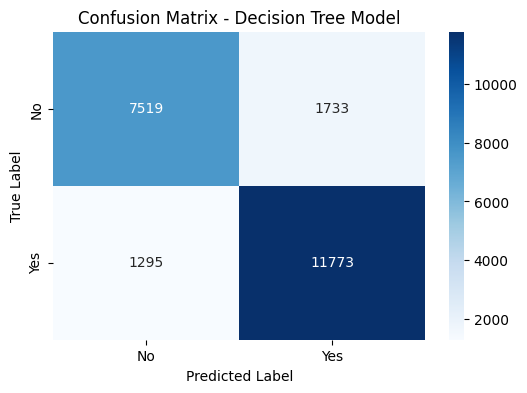

--- Đánh giá trên tập Test (Stacking Ensemble) ---
Accuracy : 0.8434
Precision: 0.8571
Recall   : 0.8791
F1-Score : 0.8680
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.82      0.79      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581



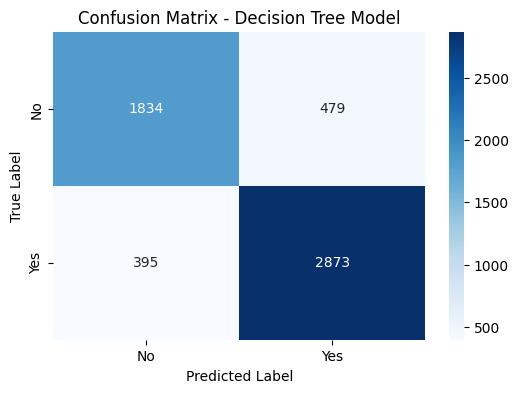

In [71]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Stacking Ensemble: mạnh hơn Voting Classifier
# base_estimators = [
#     ('rf', RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5,
#                                    min_samples_split=10, random_state=42)),
#     ('xgb', XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)),
#     ('lgb', LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
#                            num_leaves=31, random_state=42, verbose=-1)),
# ]
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=6, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1, random_state=42)),
    ('lgb', lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1)),
]
stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stacking.fit(X_train, y_train)
y_train_pred_stack = stacking.predict(X_train)
y_test_pred_stack = stacking.predict(X_test)

evaluate_model(y_train, y_train_pred_stack, 'Train (Stacking Ensemble)')
evaluate_model(y_test, y_test_pred_stack, 'Test (Stacking Ensemble)')

In [ ]:
import lightgbm as lgb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# 1. Thử với TẤT CẢ features (không feature selection)
X_all = df.drop(columns=['depression'])  # hoặc tên cột target
y_all = df['depression']

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# 2. LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train_all, y_train_all)
evaluate_model(y_test_all, lgb_model.predict(X_test_all), "LightGBM (All Features)")

# 3. Stacking Ensemble
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=6, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1, random_state=42)),
    ('lgb', lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1)),
]

stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    passthrough=True  # Dùng cả features gốc trong meta-learner
)
stacking.fit(X_train_all, y_train_all)
evaluate_model(y_test_all, stacking.predict(X_test_all), "Stacking Ensemble (All Features)")


--- Đánh giá trên tập LightGBM (All Features) ---
Accuracy : 0.8387
Precision: 0.8513
Recall   : 0.8779
F1-Score : 0.8644
--- Đánh giá trên tập Stacking Ensemble (All Features) ---
Accuracy : 0.8452
Precision: 0.8586
Recall   : 0.8807
F1-Score : 0.8695


In [ ]:
model = stacking
X = X_final
dt_acc = cross_val_score(model, X, y, scoring='accuracy', cv=5)
dt_f1 = cross_val_score(model, X, y, scoring='f1_weighted', cv=5)
dt_rec = cross_val_score(model, X, y, scoring='recall_weighted', cv=5)
dt_prec = cross_val_score(model, X, y, scoring='precision_weighted', cv=5)

print("Result K-fold:")
print("Accuracy:",dt_acc.mean(), dt_acc.std())
print("Precision:",dt_prec.mean(), dt_prec.std())
print("Recall:", dt_rec.mean(), dt_rec.std())
print("F1-score:",dt_f1.mean(), dt_f1.std())

KeyboardInterrupt: 

## Bonus

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
num_features_no_impute=['Age']
num_features_with_impute=['Fare']
cate_features=['Sex', 'Pclass', 'Embarked', 'Title', 'Family_Cate']
features_cols = num_features_no_impute + num_features_with_impute + cate_features

In [ ]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

age_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cate_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features_with_impute),
    ('age', age_transformer, num_features_no_impute),
    ('cat', cate_transformer, cate_features)
])